# Tutorial 9 – Portfolio Optimisation (GMV & Tangency)
## FINM3422 – Portfolio Management

### Objective

In this tutorial, you act as a junior portfolio analyst.

Using **historical monthly data for three ASX-listed stocks**, you will:
- estimate expected returns and the variance–covariance matrix,
- construct the **Global Minimum Variance (GMV)** portfolio,
- construct the **Tangency (Maximum Sharpe Ratio)** portfolio,
- visualise the efficient frontier and optimal portfolios, and
- produce **professional outputs** suitable for submission and reuse.

``

## 1. Environment & Imports

We use standard Python libraries and `yfinance` for data sourcing.

All modelling is done at **monthly frequency**, consistent with lectures and Assignment 2.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
np.random.seed(42)

## 2. Asset Universe and Risk‑Free Rate Assumption

We work with three large, liquid ASX stocks representing different sectors:
- BHP Group (Resources)
- Commonwealth Bank (Financials)
- CSL Limited (Healthcare / Growth)

### Risk‑Free Rate Assumption

We assume the **Australian cash rate** as the risk‑free rate.

For modelling:
- Risk‑free rate is assumed to be **3% per annum**
- Converted to **monthly** to match return frequency

This assumption is explicitly stated and documented, as required for professional modelling.

In [7]:
tickers = ["BHP.AX", "CBA.AX", "CSL.AX"]

rf_annual = 0.03
rf_monthly = rf_annual / 12


## 3. Data Sourcing (Monthly Prices)

We source **monthly adjusted prices** using `yfinance`.

Key modelling rules:
- Explicitly set frequency (`interval="1mo"`)
- Explicitly set history length (`period="max"`)
- Use adjusted prices for splits and dividends


In [8]:
prices = yf.download(
    tickers,
    period="max",
    interval="1mo",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna(how="all").sort_index()
prices.tail()


Ticker,BHP.AX,CBA.AX,CSL.AX
Date,,,
2026-01-01,49.626835,147.388443,179.111328
2026-02-01,57.320614,172.315002,144.892395
2026-03-01,49.450191,167.699997,138.988495
2026-04-01,53.720001,173.660004,124.370003
2026-05-01,58.520000,179.229996,122.000000


## 4. Return and Risk Estimation

From prices, we compute:
- monthly returns,
- expected return vector (historical mean), and
- variance–covariance matrix.

These estimates are **historical proxies**, not forecasts.


In [ ]:
returns = prices.pct_change().dropna()

mu = returns.mean().values          # expected returns vector
Sigma = returns.cov().values        # covariance matrix

mu, Sigma


(array([0.01216106, 0.01432399, 0.01739337]),
 array([[0.0052657 , 0.00085702, 0.00050888],
        [0.00085702, 0.00338389, 0.00066803],
        [0.00050888, 0.00066803, 0.00592011]]))

## 5. Global Minimum Variance (GMV) Portfolio

The **Global Minimum Variance (GMV)** portfolio is the portfolio with the **lowest possible
total risk**, measured by portfolio variance.

Key characteristics of the GMV portfolio:
- It depends **only on the covariance matrix**, not on expected returns
- It focuses purely on **risk reduction**
- It is often used by very risk‑averse investors or as a diversification benchmark

### Portfolio Variance Formula

The variance of a portfolio is given by:

$$
\sigma_p^2 = \sum_{i=1}^{N} \sum_{j=1}^{N} w_i \, w_j \, \sigma_{ij}
$$

Where:
- $w_i$ = weight of asset $i$
- $\sigma_{ij}$ = covariance between asset $i$ and asset $j$

### How We Find the GMV Portfolio in Practice

Rather than using advanced matrix algebra, we:
1. Simulate many random portfolios  
2. Compute the portfolio variance for each portfolio using **nested loops**  
3. Select the portfolio with the **smallest variance**



In [10]:
# ---- GMV Portfolio (given – explained by tutor) ----

def portfolio_variance(weights, Sigma):
    """
    Computes portfolio variance using the covariance matrix
    and explicit nested loops.
    """
    var = 0
    n = len(weights)
    
    for i in range(n):
        for j in range(n):
            var += weights[i] * weights[j] * Sigma[i, j]
            
    return var


# Simulate random portfolios
n_portfolios = 5000
weights = np.random.dirichlet(np.ones(len(tickers)), n_portfolios)

portfolio_vars = []

for w in weights:
    portfolio_vars.append(portfolio_variance(w, Sigma))

portfolio_vars = np.array(portfolio_vars)

# Identify GMV portfolio
gmv_index = portfolio_vars.argmin()
w_gmv = weights[gmv_index]

w_gmv

array([0.27593724, 0.4645716 , 0.25949115])

## 6. Tangency (Maximum Sharpe Ratio) Portfolio

The **Tangency Portfolio** is the portfolio that maximises the **Sharpe ratio**.
It represents the **optimal risky portfolio** in portfolio theory and CAPM.

### Sharpe Ratio

The Sharpe ratio is defined as:

$$
\text{Sharpe Ratio} = \frac{E(R_p) - r_f}{\sigma_p}
$$

Where:
- $E(R_p)$ = expected portfolio return
- $r_f$ = risk‑free rate (monthly)
- $\sigma_p$ = portfolio volatility

### How We Find the Tangency Portfolio

Using the **same simulated portfolios** as before:
1. Compute portfolio return  
2. Compute portfolio variance and volatility  
3. Compute the Sharpe ratio  
4. Select the portfolio with the **highest Sharpe ratio**

You will complete this step using **nested loops**, following the same logic
used for the GMV portfolio.
``

In [11]:
# ---- Tangency Portfolio (student work) ----

portfolio_returns = []
portfolio_vols = []
portfolio_sharpes = []

for w in weights:
    
    # TODO 1: Compute portfolio return
    # Hint: portfolio return = sum of weights * expected returns
    port_return = np.sum(w * mu)
    
    # TODO 2: Compute portfolio variance using the function from Section 5
    port_variance = portfolio_variance(w, Sigma)
    
    # TODO 3: Compute portfolio volatility
    port_vol = np.sqrt(port_variance)
    
    # TODO 4: Compute Sharpe ratio
    sharpe = (port_return - rf_monthly) / port_vol
    
    portfolio_returns.append(port_return)
    portfolio_vols.append(port_vol)
    portfolio_sharpes.append(sharpe)

portfolio_sharpes = np.array(portfolio_sharpes)

# TODO 5: Identify the tangency portfolio (maximum Sharpe ratio)
tan_index = portfolio_sharpes.argmax()
w_tan = weights[tan_index]

w_tan


array([0.19513034, 0.46083227, 0.34403739])

## 7. Portfolio Characteristics

We compare GMV and Tangency portfolios in terms of:
- expected return,
- volatility, and
- Sharpe ratio.

In [12]:
def portfolio_performance(weights, mu, Sigma, rf):
    ret = weights @ mu
    vol = np.sqrt(weights @ Sigma @ weights)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

gmv_perf = portfolio_performance(w_gmv, mu, Sigma, rf_monthly)
tan_perf = portfolio_performance(w_tan, mu, Sigma, rf_monthly)

pd.DataFrame(
    [gmv_perf, tan_perf],
    columns=["Expected Return", "Volatility", "Sharpe Ratio"],
    index=["GMV", "Tangency"]
)


,Expected Return,Volatility,Sharpe Ratio
GMV,0.014524,0.044537,0.269967
Tangency,0.014958,0.045322,0.274874


## 8. Efficient Frontier (Simulation)

We simulate many random portfolios to visualise:
- the efficient frontier,
- the GMV portfolio, and
- the Tangency portfolio.

In [15]:
n_portfolios = 5000
weights_random = np.random.dirichlet(np.ones(len(mu)), n_portfolios)

returns_sim = weights_random @ mu
vols_sim = np.sqrt(np.einsum("ij,jk,ik->i", weights_random, Sigma, weights_random))
sharpes_sim = (returns_sim - rf_monthly) / vols_sim


## 9. Portfolio Optimisation Visualisation

This chart summarises the optimisation:
- Efficient frontier (simulated portfolios)
- Global Minimum Variance portfolio
- Tangency (Maximum Sharpe) portfolio
``

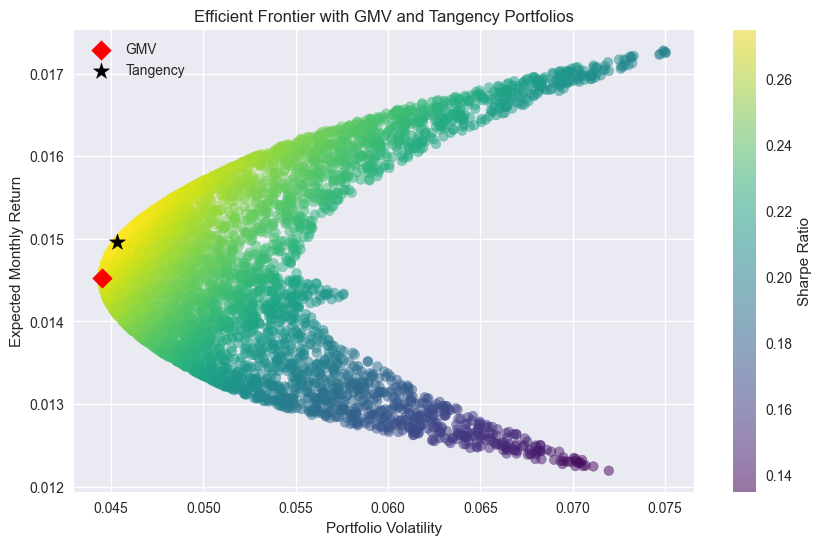

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(vols_sim, returns_sim, c=sharpes_sim, cmap="viridis", alpha=0.5)
plt.colorbar(label="Sharpe Ratio")

plt.scatter(gmv_perf[1], gmv_perf[0], marker="D", color="red", s=100, label="GMV")
plt.scatter(tan_perf[1], tan_perf[0], marker="*", color="black", s=150, label="Tangency")

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Monthly Return")
plt.title("Efficient Frontier with GMV and Tangency Portfolios")
plt.legend()
plt.show()


## 10. Interpretation

- The **GMV portfolio** minimises risk but does not maximise returns.
- The **Tangency portfolio** offers the highest risk‑adjusted return.
- Differences in weights arise from:
  - return estimates,
  - volatility, and
  - correlations between assets.

This trade‑off lies at the heart of portfolio management.

## Exporting Your Notebook (Recommended Method)

### Using VS Code (No Terminal Required)

1. Open this notebook in **VS Code**
2. Press **Ctrl + Shift + P** (Windows/Linux) or **Cmd + Shift + P** (macOS)
3. Type **Jupyter: Export Notebook As...**
4. Choose **HTML** (recommended) or **PDF** (optional)

The exported file will be saved in the same folder as the notebook.

HTML export does not require any additional installation and is sufficient for
Assignment 2 – Task 3.5.